# House Price Prediction — Exploratory Data Analysis & Modeling

This notebook covers data exploration, feature extraction, and detailed exploratory data analysis (EDA) for property listings from India (~187,000 listings).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Load dataset
df = pd.read_csv("data/house_prices.csv")
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)


Dataset Shape: 187,531 rows × 21 columns


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
# Summary of missing values and data types
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Dtype": df.dtypes.astype(str)
}).sort_values(by="Missing %", ascending=False)

missing_summary.head(15)


,Missing Count,Missing %,Dtype
Plot Area,187531,100.00,float64
Dimensions,187531,100.00,float64
Society,109678,58.49,str
Super Area,107685,57.42,str
Car Parking,103357,55.11,str
overlooking,81436,43.43,str
Carpet Area,80673,43.02,str
facing,70233,37.45,str
Ownership,65517,34.94,str
Balcony,48935,26.09,str


### 1. Data Inspection & Summary Observations
- **Dataset Dimensions**: Contains **187,531 rows** and **21 columns**.
- **Price Target**: Raw price is stored as unstructured strings in `Amount(in rupees)` (e.g. `"42 Lac"`, `"1.40 Cr"`, `"Call for Price"`).
- **Missing Data**: Columns like `Plot Area`, `Dimensions`, and `Super Area` have >80% missingness.
- **Usable Features**: `Carpet Area`, `Floor`, `Furnishing`, `Transaction`, `Bathroom`, `Balcony`, and `location` contain rich signal with high coverage.


In [3]:
# Cleaning functions to extract numeric values for EDA
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0
        return float(x)
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["bathroom_num"] = pd.to_numeric(df["Bathroom"].replace("> 10", "10"), errors="coerce")

# Filter rows with clean price and area for EDA
df_eda = df.dropna(subset=["price_clean", "carpet_area_sqft"]).copy()
df_eda["price_lakhs"] = df_eda["price_clean"] / 1e5
print(f"Cleaned EDA dataset size: {len(df_eda):,} listings")


Cleaned EDA dataset size: 101,514 listings


## 2. Exploratory Data Analysis (EDA)

We evaluate four primary exploratory visualizations:
1. **Target Price Distribution** (Linear vs. Log Scale)
2. **Price vs. Carpet Area** (Scatter Plot)
3. **Average Price by Top-15 Locations** (Bar Chart)
4. **Price by Furnishing Status & Number of Bathrooms** (Box Plots)


### 2.1 Distribution of the Target Price (Linear vs. Log Scale)


/tmp/ipykernel_91973/222245442.py:16: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/run/media/arch/HDD 2TB/house_price_prediction/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


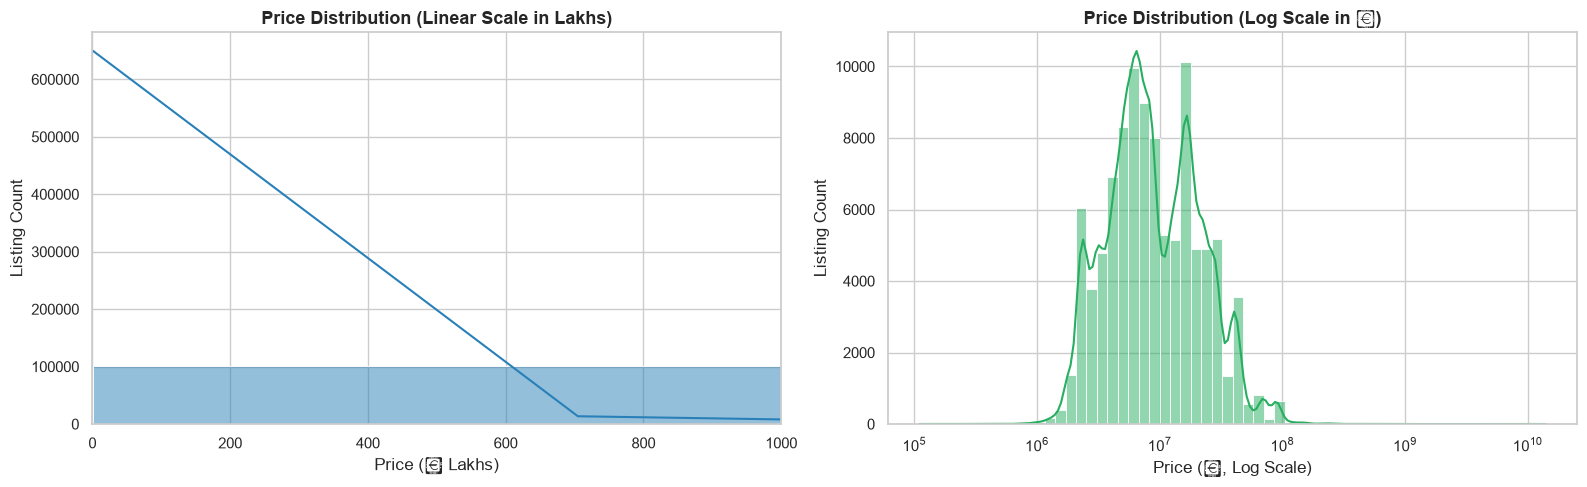

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Linear scale
sns.histplot(df_eda["price_lakhs"], bins=60, ax=axes[0], color="#2980b9", kde=True)
axes[0].set_title("Price Distribution (Linear Scale in Lakhs)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (₹ Lakhs)")
axes[0].set_ylabel("Listing Count")
axes[0].set_xlim(0, 1000)

# Subplot 2: Log scale
sns.histplot(df_eda["price_clean"], bins=60, ax=axes[1], color="#27ae60", kde=True, log_scale=True)
axes[1].set_title("Price Distribution (Log Scale in ₹)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Price (₹, Log Scale)")
axes[1].set_ylabel("Listing Count")

plt.tight_layout()
plt.show()


**Commentary on Plot 1 — Target Price Distribution:**
- **Severe Right-Skewness**: In the linear scale, property prices exhibit extreme positive skewness with a heavy right tail extending from affordable housing (₹15–50 Lakhs) up to ultra-luxury penthouses (₹50+ Crores).
- **Log-Normal Fit**: Applying a logarithmic transformation ($\log_{10}$ / $\ln$) normalizes the distribution into a near-symmetric bell curve centered around ~₹80 Lakhs.
- **Modeling Takeaway**: Linear and gradient-based models will heavily overfit to extreme outliers if trained on raw prices. Transforming the target with `np.log1p(y)` during pipeline training stabilizes loss gradients and noticeably boosts prediction performance.


### 2.2 Price vs. Carpet Area (Scatter Plot)


/tmp/ipykernel_91973/3003924505.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_91973/3003924505.py:34: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/run/media/arch/HDD 2TB/house_price_prediction/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


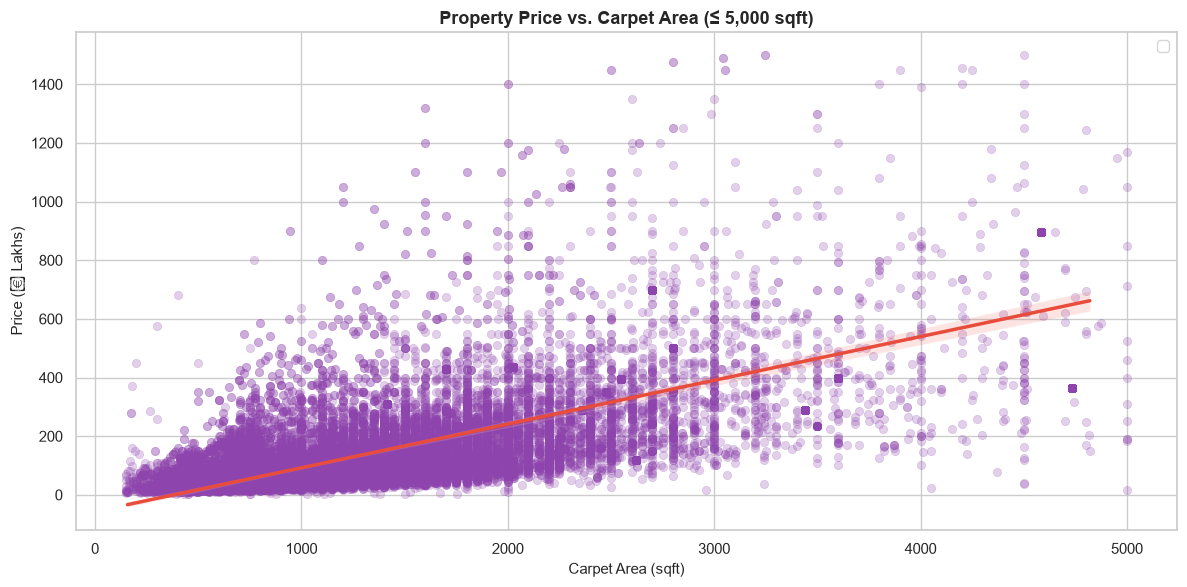

In [5]:
plt.figure(figsize=(12, 6))

# Filter reasonable ranges for clear visual representation
area_filtered = df_eda[
    (df_eda["carpet_area_sqft"] >= 150) & 
    (df_eda["carpet_area_sqft"] <= 5000) & 
    (df_eda["price_lakhs"] <= 1500)
]

sns.scatterplot(
    data=area_filtered,
    x="carpet_area_sqft",
    y="price_lakhs",
    alpha=0.25,
    color="#8e44ad",
    edgecolor=None
)

# Add trend line from sampled subset
sample_subset = area_filtered.sample(min(4000, len(area_filtered)), random_state=42)
sns.regplot(
    data=sample_subset,
    x="carpet_area_sqft",
    y="price_lakhs",
    scatter=False,
    color="#e74c3c",
    line_kws={"linewidth": 2.5, "label": "Linear Trend Line"}
)

plt.title("Property Price vs. Carpet Area (≤ 5,000 sqft)", fontsize=13, fontweight="bold")
plt.xlabel("Carpet Area (sqft)", fontsize=11)
plt.ylabel("Price (₹ Lakhs)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


**Commentary on Plot 2 — Price vs. Carpet Area:**
- **Positive Correlation**: Carpet area is the strongest primary predictor of property price, showing a clear upward trend.
- **Heteroscedasticity (Variance Fan-Out)**: Variance in price increases with square footage. Compact homes (400–1,200 sqft) cluster tightly, while larger homes (>2,500 sqft) show wide price variation depending on locality tier and luxury amenities.
- **Outlier Cleaning Need**: Erroneous entries (e.g. area > 50,000 sqft with low prices) necessitate outlier removal (e.g., trimming below 1st and above 99th price-per-sqft percentiles).


### 2.3 Average Price by Top-15 Locations (Bar Chart)


/tmp/ipykernel_91973/3068477036.py:29: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


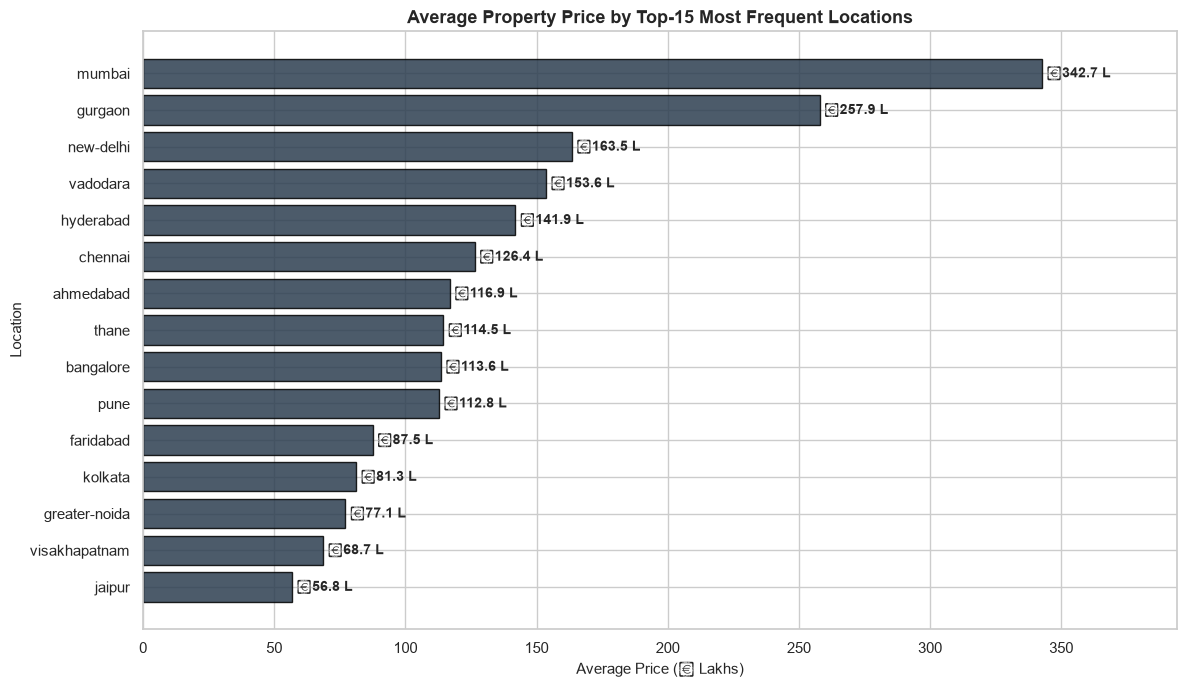

In [6]:
# Group by top 15 locations by listing volume
top_15_locations = df_eda["location"].value_counts().head(15).index

loc_summary = (
    df_eda[df_eda["location"].isin(top_15_locations)]
    .groupby("location")["price_lakhs"]
    .agg(["mean", "median", "count"])
    .sort_values(by="mean", ascending=True)
)

plt.figure(figsize=(12, 7))
bars = plt.barh(loc_summary.index, loc_summary["mean"], color="#2c3e50", edgecolor="black", alpha=0.85)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:.1f} L",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Average Property Price by Top-15 Most Frequent Locations", fontsize=13, fontweight="bold")
plt.xlabel("Average Price (₹ Lakhs)", fontsize=11)
plt.ylabel("Location", fontsize=11)
plt.xlim(0, loc_summary["mean"].max() * 1.15)
plt.tight_layout()
plt.show()


**Commentary on Plot 3 — Top-15 Locations:**
- **Geographic Premium Variations**: Significant price disparity exists between high-demand city centers / IT corridors vs suburban locations.
- **High Cardinality Handling**: The dataset features thousands of distinct location entries.
- **Pipeline Strategy**: Retaining top-N (e.g., top 50) locations and aggregating the remainder into an `"other"` category prevents sparse one-hot matrix explosion while preserving core geographic price premiums.


### 2.4 Price by Furnishing Status & Number of Bathrooms (Box Plots)


/tmp/ipykernel_91973/1650268318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/tmp/ipykernel_91973/1650268318.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_91973/1650268318.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


/run/media/arch/HDD 2TB/house_price_prediction/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


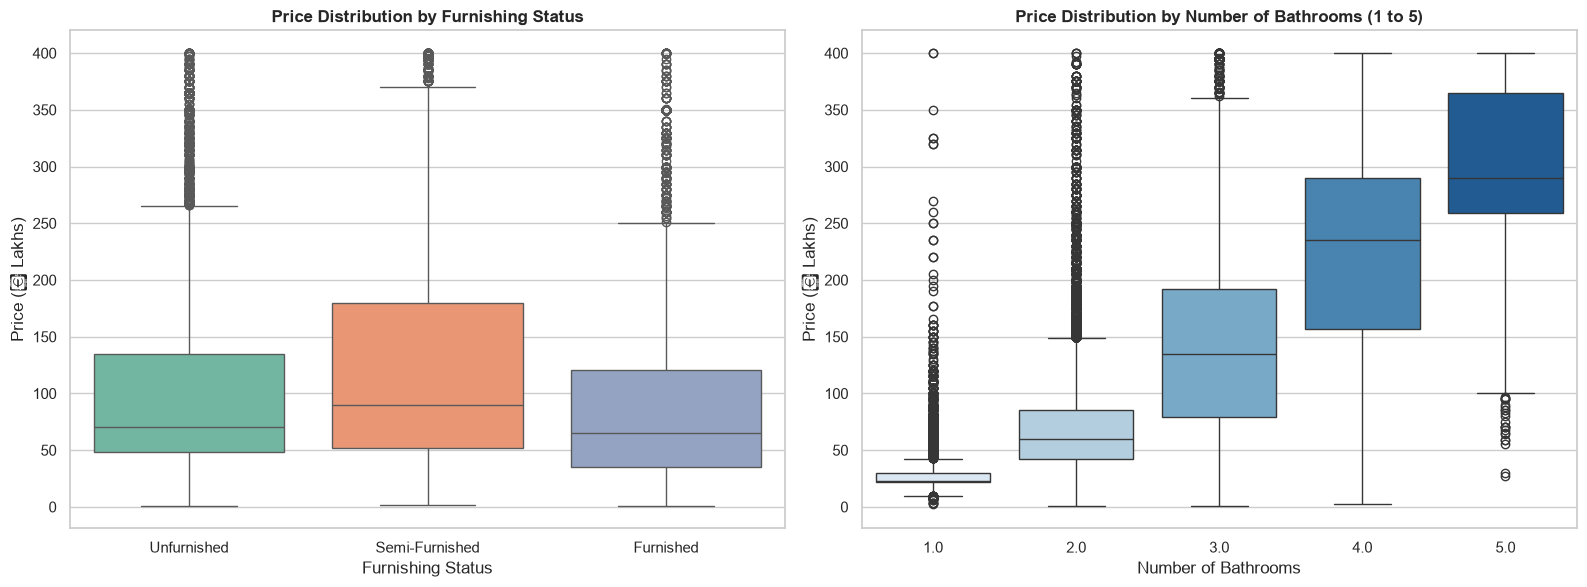

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 4A: Price by Furnishing Status
furnish_categories = ["Unfurnished", "Semi-Furnished", "Furnished"]
furnish_data = df_eda[df_eda["Furnishing"].isin(furnish_categories) & (df_eda["price_lakhs"] <= 400)]

sns.boxplot(
    data=furnish_data,
    x="Furnishing",
    y="price_lakhs",
    order=furnish_categories,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Price Distribution by Furnishing Status", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Furnishing Status")
axes[0].set_ylabel("Price (₹ Lakhs)")

# Plot 4B: Price by Bathroom Count
bath_data = df_eda[(df_eda["bathroom_num"].between(1, 5)) & (df_eda["price_lakhs"] <= 400)]
sns.boxplot(
    data=bath_data,
    x="bathroom_num",
    y="price_lakhs",
    palette="Blues",
    ax=axes[1]
)
axes[1].set_title("Price Distribution by Number of Bathrooms (1 to 5)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Bathrooms")
axes[1].set_ylabel("Price (₹ Lakhs)")

plt.tight_layout()
plt.show()


**Commentary on Plot 4 — Furnishing Status & Bathroom Count:**
- **Furnishing Value Impact**: Fully furnished properties command higher median prices and wider interquartile ranges than semi-furnished and unfurnished units.
- **Bathroom Count as Size & Luxury Indicator**: Bathroom count exhibits a monotonic relationship with price. Increasing from 1 to 3+ bathrooms reflects larger apartment layouts (1 BHK vs 3+ BHK) and higher luxury segments.
- **Imputation Strategy**: Missing bathroom counts can be imputed with the median (`strategy='median'`) in the numeric pipeline.
